# RuIntona — исследование LMDB-корпусов

Детальная статистика по ключевым LMDB-корпусам проекта и проверка качества train/test-разбиений.

**Корпуса:**
- `combine_balanced` — сбалансированный набор (Dusha crowd + podcast, 4 эмоции)
- `combine_balanced_small` — уменьшенный вариант (~30% от balanced)
- `dusha_resd` — Dusha crowd + RESD (Aniemore/resd_annotated, студийная речь)

**Эмоции**: `angry` (0), `sad` (1), `neutral` (2), `positive` (3).

Подробнее о корпусах — [CORPUS.md](../../../../CORPUS.md).

In [1]:
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

if matplotlib.get_backend().lower() == "agg":
    plt.show = lambda *args, **kwargs: None


def _find_project_root():
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "ruintona" / "my_experiments").is_dir():
            return cand
    raise RuntimeError("Корень репозитория не найден")


PROJECT_ROOT = _find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

from ruintona.my_experiments.utils.config_utils import DATASET_PATH, EMO2LABEL, TARGET_NAMES  # noqa: E402
from ruintona.my_experiments.utils.lmdb_utils import (  # noqa: E402
    open_lmdb_readonly, get_lmdb_length, safe_pickle_loads, LABEL2EMO,
)

if DATASET_PATH is None:
    raise SystemExit(
        "data.json не найден. Создайте ruintona/my_experiments/data.json из data.json.example."
    )

sns.set_palette("husl")
plt.style.use("seaborn-v0_8-darkgrid")
EMO_COLORS = {"angry": "#e74c3c", "sad": "#3498db", "neutral": "#95a5a6", "positive": "#2ecc71"}

AGG = DATASET_PATH / "lmdb" / "aggregated_dataset"

print("[D] Датасет: <base_path>")
print("[D] LMDB:    <base_path>/lmdb/aggregated_dataset/")
print(f"Целевые эмоции: {TARGET_NAMES}")

[D] Датасет: <base_path>
[D] LMDB:    <base_path>/lmdb/aggregated_dataset/
Целевые эмоции: ['angry', 'sad', 'neutral', 'positive']


---
## Блок 1 — Train-корпуса

In [2]:
def load_lmdb_metadata(path: Path) -> list[dict]:
    """Загружает метаданные из LMDB (без массивов waveform/x)."""
    env = open_lmdb_readonly(path)
    try:
        total = get_lmdb_length(env)
        records = []
        with env.begin() as txn:
            for idx in range(total):
                raw = txn.get(str(idx).encode("utf-8"))
                if raw is None:
                    continue
                payload = safe_pickle_loads(raw)
                if not isinstance(payload, dict):
                    continue
                rec = {
                    "id": payload.get("id", ""),
                    "y": payload.get("y"),
                    "emotion": LABEL2EMO.get(payload.get("y"), "unknown"),
                    "text": str(payload.get("text", "")),
                    "n_chars": len(str(payload.get("text", ""))),
                    "n_words": len(str(payload.get("text", "")).split()),
                }
                wf = payload.get("waveform")
                if wf is not None and hasattr(wf, "__len__") and len(wf) > 0:
                    sr = payload.get("waveform_sr", 16000)
                    rec["duration"] = len(wf) / sr
                    rec["waveform_all_zero"] = bool(np.all(wf == 0))
                else:
                    rec["duration"] = None
                    rec["waveform_all_zero"] = True
                records.append(rec)
        return records
    finally:
        env.close()


TRAIN_CORPORA = {
    "combine_balanced_train": AGG / "combine_balanced_train.lmdb",
    "combine_balanced_train_small": AGG / "combine_balanced_train_small.lmdb",
    "dusha_resd_train": AGG / "dusha_resd_train.lmdb",
}

train_data = {}
for name, path in TRAIN_CORPORA.items():
    if path.exists():
        print(f"[...] Загрузка {name}...")
        train_data[name] = load_lmdb_metadata(path)
        print(f"  [OK] {name}: {len(train_data[name]):,} записей")
    else:
        print(f"  [MISSING] {name} ОТСУТСТВУЕТ: {path}")

[...] Загрузка combine_balanced_train...


  [OK] combine_balanced_train: 68,203 записей
[...] Загрузка combine_balanced_train_small...


  [OK] combine_balanced_train_small: 20,474 записей
[...] Загрузка dusha_resd_train...


  [OK] dusha_resd_train: 69,119 записей


### 1.1 Сводная таблица

In [3]:
def build_summary(data: dict[str, list[dict]]) -> pd.DataFrame:
    """Строит сводную таблицу по корпусам."""
    rows = []
    for name, records in data.items():
        durations = [r["duration"] for r in records if r["duration"] is not None]
        texts = [r["text"] for r in records if r["text"] and r["text"] != "nan"]
        emo_counts = Counter(r["emotion"] for r in records)
        total_hours = sum(durations) / 3600 if durations else 0
        rows.append({
            "Корпус": name,
            "Записей": len(records),
            "Часов": round(total_hours, 2),
            "Средняя длительность (с)": round(np.mean(durations), 2) if durations else 0,
            "Медиана длительность (с)": round(np.median(durations), 2) if durations else 0,
            "% с текстом": round(100 * len(texts) / len(records), 1) if records else 0,
            "angry": emo_counts.get("angry", 0),
            "sad": emo_counts.get("sad", 0),
            "neutral": emo_counts.get("neutral", 0),
            "positive": emo_counts.get("positive", 0),
        })
    return pd.DataFrame(rows)


train_summary = build_summary(train_data)
display(train_summary.style.hide(axis="index").format(
    precision=2,
    subset=["Часов", "Средняя длительность (с)", "Медиана длительность (с)", "% с текстом"]
).format("{:}", subset=["Записей", "angry", "sad", "neutral", "positive"]))

Корпус,Записей,Часов,Средняя длительность (с),Медиана длительность (с),% с текстом,angry,sad,neutral,positive
combine_balanced_train,68203,90.31,4.77,4.52,98.20,14435,21049,18520,14199
combine_balanced_train_small,20474,27.05,4.76,4.52,98.20,4344,6337,5564,4229
dusha_resd_train,69119,91.84,4.78,4.52,98.20,14639,21269,18703,14508


### 1.2 Распределение эмоций

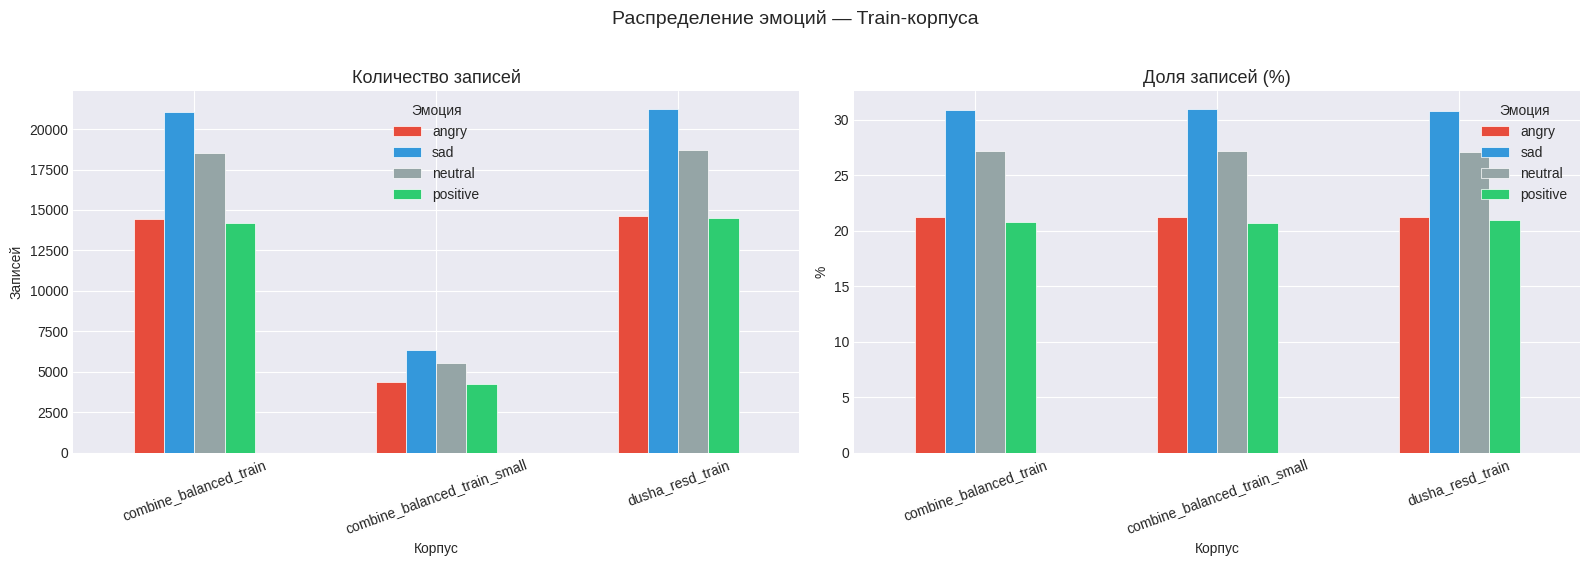


[P] Imbalance ratio (max/min po klassam):
               combine_balanced_train: 1.48x  (min=14,199, max=21,049)
         combine_balanced_train_small: 1.50x  (min=4,229, max=6,337)
                     dusha_resd_train: 1.47x  (min=14,508, max=21,269)


In [4]:
def plot_emotion_distribution(data: dict[str, list[dict]],
                              title: str = "Распределение эмоций") -> pd.DataFrame:
    """Групповая диаграмма распределения эмоций по корпусам."""
    emo_rows = []
    for name, records in data.items():
        counts = Counter(r["emotion"] for r in records)
        total = len(records)
        for emo in TARGET_NAMES:
            emo_rows.append({
                "Корпус": name,
                "Эмоция": emo,
                "Количество": counts.get(emo, 0),
                "Доля (%)": round(100 * counts.get(emo, 0) / total, 1) if total else 0,
            })
    emo_df = pd.DataFrame(emo_rows)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

    pivot_abs = emo_df.pivot(index="Корпус", columns="Эмоция",
                              values="Количество")
    pivot_abs[TARGET_NAMES].plot(kind="bar", ax=axes[0],
                                 color=[EMO_COLORS[e] for e in TARGET_NAMES],
                                 edgecolor="white", linewidth=0.5)
    axes[0].set_title("Количество записей", fontsize=13)
    axes[0].set_ylabel("Записей")
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].legend(title="Эмоция")

    pivot_pct = emo_df.pivot(index="Корпус", columns="Эмоция",
                              values="Доля (%)")
    pivot_pct[TARGET_NAMES].plot(kind="bar", ax=axes[1],
                                 color=[EMO_COLORS[e] for e in TARGET_NAMES],
                                 edgecolor="white", linewidth=0.5)
    axes[1].set_title("Доля записей (%)", fontsize=13)
    axes[1].set_ylabel("%")
    axes[1].tick_params(axis="x", rotation=20)
    axes[1].legend(title="Эмоция")

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    print("\n[P] Imbalance ratio (max/min po klassam):")
    for name, records in data.items():
        counts = Counter(r["emotion"] for r in records)
        vals = [counts.get(e, 0) for e in TARGET_NAMES]
        non_zero = [v for v in vals if v > 0]
        ratio = max(non_zero) / min(non_zero) if non_zero else float("inf")
        print(f"  {name:>35}: {ratio:.2f}x  (min={min(non_zero):,}, max={max(non_zero):,})")

    return emo_df


train_emo_df = plot_emotion_distribution(train_data, "Распределение эмоций — Train-корпуса")

### 1.3 Качество данных (нулевые / битые записи)

In [5]:
def check_quality(data: dict[str, list[dict]]) -> pd.DataFrame:
    """Проверяет наличие проблем в записях LMDB."""
    rows = []
    for name, records in data.items():
        n = len(records)
        if n == 0:
            continue
        n_empty_id = sum(1 for r in records if not r["id"])
        n_nan_y = sum(1 for r in records if r["y"] is None or r["emotion"] == "unknown")
        n_empty_text = sum(1 for r in records if not r["text"] or r["text"] == "nan")
        n_wf_zero = sum(1 for r in records if r.get("waveform_all_zero", False))
        n_dur_none = sum(1 for r in records if r["duration"] is None)
        rows.append({
            "Корпус": name,
            "Всего": n,
            "Пустой id": f"{n_empty_id} ({100*n_empty_id/n:.1f}%)",
            "Некорректный y": f"{n_nan_y} ({100*n_nan_y/n:.1f}%)",
            "Пустой text": f"{n_empty_text} ({100*n_empty_text/n:.1f}%)",
            "Waveform = 0": f"{n_wf_zero} ({100*n_wf_zero/n:.1f}%)",
            "Нет длительности": f"{n_dur_none} ({100*n_dur_none/n:.1f}%)",
        })
    quality_df = pd.DataFrame(rows)
    display(quality_df.style.hide(axis="index"))

    for name, records in data.items():
        n = len(records)
        n_wf_zero = sum(1 for r in records if r.get("waveform_all_zero", False))
        n_nan_y = sum(1 for r in records if r["y"] is None or r["emotion"] == "unknown")
        if n_wf_zero == 0 and n_nan_y == 0:
            print(f"  [OK] {name}: все записи валидны")
        else:
            if n_wf_zero > 0:
                print(f"  [!]  {name}: {n_wf_zero} записей с нулевым waveform")
            if n_nan_y > 0:
                print(f"  [!]  {name}: {n_nan_y} записей с некорректной меткой")

    return quality_df


train_quality = check_quality(train_data)

Корпус,Всего,Пустой id,Некорректный y,Пустой text,Waveform = 0,Нет длительности
combine_balanced_train,68203,0 (0.0%),0 (0.0%),1231 (1.8%),0 (0.0%),0 (0.0%)
combine_balanced_train_small,20474,0 (0.0%),0 (0.0%),364 (1.8%),0 (0.0%),0 (0.0%)
dusha_resd_train,69119,0 (0.0%),0 (0.0%),1231 (1.8%),0 (0.0%),0 (0.0%)


  [OK] combine_balanced_train: все записи валидны
  [OK] combine_balanced_train_small: все записи валидны
  [OK] dusha_resd_train: все записи валидны


### 1.4 Анализ длительностей

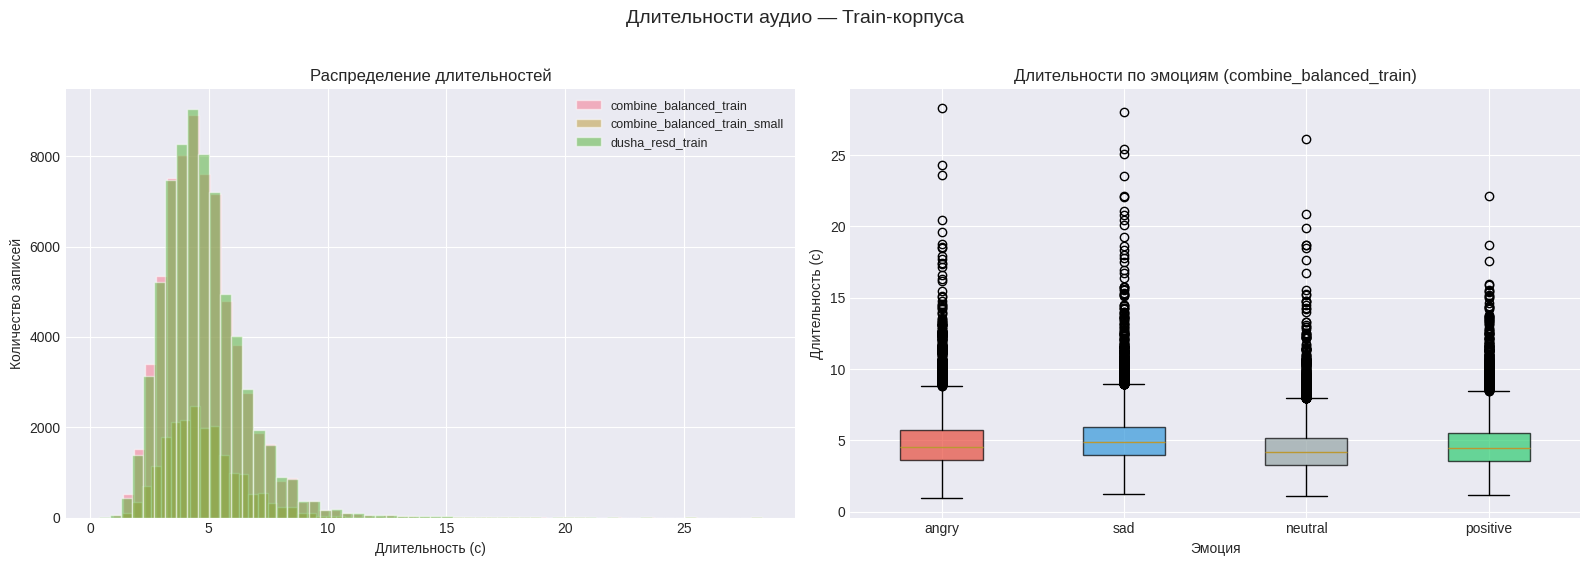

Корпус,N,Mean,Median,Std,Min,P90,P95,Max
combine_balanced_train,68203,4.77,4.52,1.69,0.95,6.86,7.72,28.28
combine_balanced_train_small,20474,4.76,4.52,1.69,0.95,6.84,7.72,25.44
dusha_resd_train,69119,4.78,4.52,1.75,0.37,6.92,7.82,28.28


In [6]:
def plot_durations(data: dict[str, list[dict]],
                   title: str = "Длительности аудио"):
    """Гистограмма длительностей + boxplot по эмоциям."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

    for name, records in data.items():
        durations = [r["duration"] for r in records if r["duration"] is not None]
        axes[0].hist(durations, bins=60, alpha=0.5, label=name, edgecolor="white")
    axes[0].set_title("Распределение длительностей")
    axes[0].set_xlabel("Длительность (с)")
    axes[0].set_ylabel("Количество записей")
    axes[0].legend(fontsize=9)

    first_name = list(data.keys())[0]
    first_records = data[first_name]
    durations_by_emo = {
        e: [r["duration"] for r in first_records
            if r["emotion"] == e and r["duration"] is not None]
        for e in TARGET_NAMES
    }
    bp = axes[1].boxplot(
        [durations_by_emo[e] for e in TARGET_NAMES],
        tick_labels=TARGET_NAMES, patch_artist=True,
    )
    for patch, emo in zip(bp["boxes"], TARGET_NAMES):
        patch.set_facecolor(EMO_COLORS[emo])
        patch.set_alpha(0.7)
    axes[1].set_title(f"Длительности по эмоциям ({first_name})")
    axes[1].set_xlabel("Эмоция")
    axes[1].set_ylabel("Длительность (с)")

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    stats_rows = []
    for name, records in data.items():
        durations = [r["duration"] for r in records if r["duration"] is not None]
        if not durations:
            continue
        arr = np.array(durations)
        stats_rows.append({
            "Корпус": name,
            "N": len(arr),
            "Mean": round(float(arr.mean()), 2),
            "Median": round(float(np.median(arr)), 2),
            "Std": round(float(arr.std()), 2),
            "Min": round(float(arr.min()), 2),
            "P90": round(float(np.percentile(arr, 90)), 2),
            "P95": round(float(np.percentile(arr, 95)), 2),
            "Max": round(float(arr.max()), 2),
        })
    display(pd.DataFrame(stats_rows).style.hide(axis="index").format(precision=2))


plot_durations(train_data, "Длительности аудио — Train-корпуса")

### 1.5 Анализ текстов

Корпус,% с текстом
combine_balanced_train,98.2
combine_balanced_train_small,98.2
dusha_resd_train,98.2


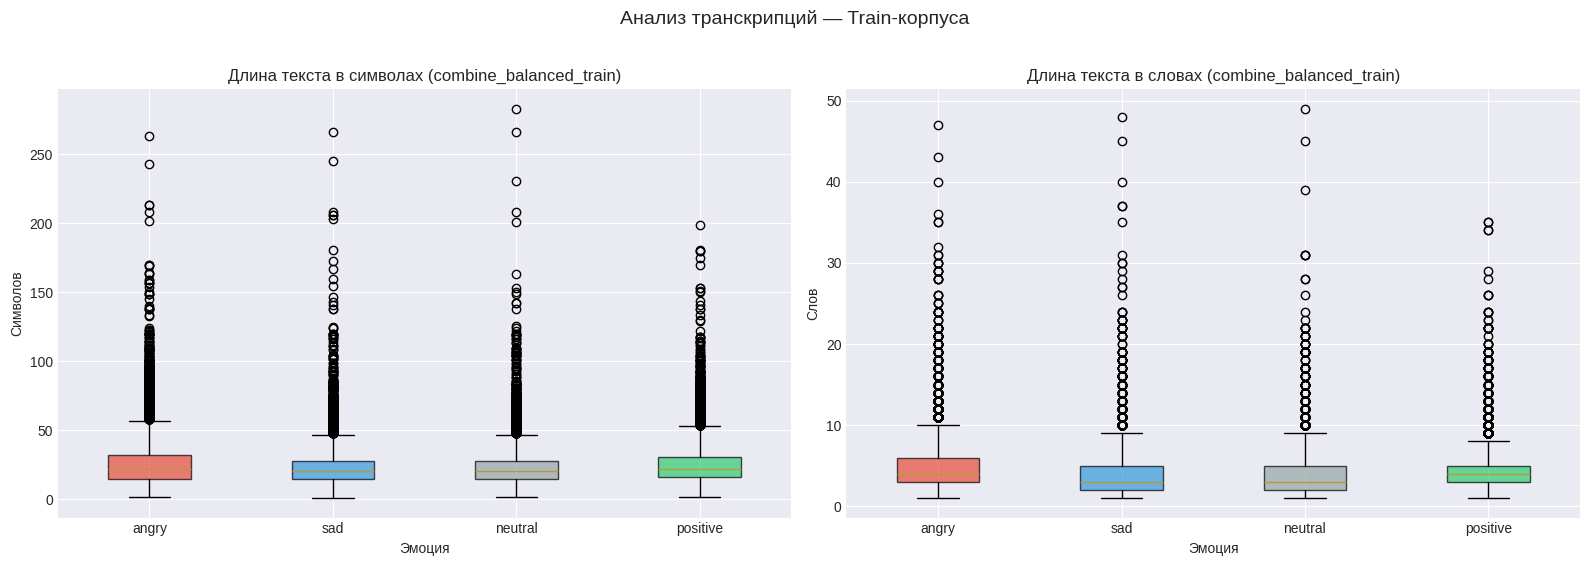

In [7]:
def plot_texts(data: dict[str, list[dict]],
               title: str = "Анализ транскрипций"):
    """Длины текстов по эмоциям + % записей с текстом."""
    pct_rows = []
    for name, records in data.items():
        n_total = len(records)
        n_with_text = sum(1 for r in records
                          if r["text"] and r["text"] != "nan" and r["n_chars"] > 0)
        pct_rows.append({
            "Корпус": name,
            "% с текстом": round(100 * n_with_text / n_total, 1) if n_total else 0,
        })
    display(pd.DataFrame(pct_rows).style.hide(axis="index").format(precision=1))

    first_name = list(data.keys())[0]
    first_records = data[first_name]
    chars_by_emo = {
        e: [r["n_chars"] for r in first_records
            if r["emotion"] == e and r["n_chars"] > 0]
        for e in TARGET_NAMES
    }
    words_by_emo = {
        e: [r["n_words"] for r in first_records
            if r["emotion"] == e and r["n_words"] > 0]
        for e in TARGET_NAMES
    }

    fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

    bp1 = axes[0].boxplot(
        [chars_by_emo[e] for e in TARGET_NAMES],
        tick_labels=TARGET_NAMES, patch_artist=True,
    )
    for patch, emo in zip(bp1["boxes"], TARGET_NAMES):
        patch.set_facecolor(EMO_COLORS[emo])
        patch.set_alpha(0.7)
    axes[0].set_title(f"Длина текста в символах ({first_name})")
    axes[0].set_xlabel("Эмоция")
    axes[0].set_ylabel("Символов")

    bp2 = axes[1].boxplot(
        [words_by_emo[e] for e in TARGET_NAMES],
        tick_labels=TARGET_NAMES, patch_artist=True,
    )
    for patch, emo in zip(bp2["boxes"], TARGET_NAMES):
        patch.set_facecolor(EMO_COLORS[emo])
        patch.set_alpha(0.7)
    axes[1].set_title(f"Длина текста в словах ({first_name})")
    axes[1].set_xlabel("Эмоция")
    axes[1].set_ylabel("Слов")

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_texts(train_data, "Анализ транскрипций — Train-корпуса")

### 1.6 Пересечение корпусов (combine_balanced ∩ dusha_resd)

Пара,Пересечение,% от combine_balanced_train,% от dusha_resd_train
combine_balanced_train ∩ dusha_resd_train,68203,100.0,98.7


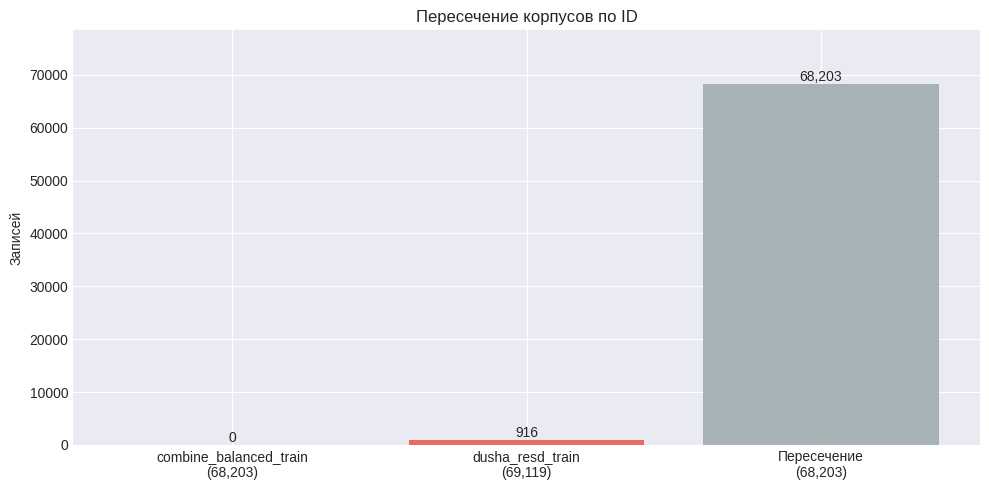

In [8]:
def plot_intersection(data: dict[str, list[dict]],
                      title: str = "Пересечение корпусов по ID"):
    """UpSet plot или таблица пересечений."""
    id_sets = {
        name: set(r["id"] for r in records if r["id"])
        for name, records in data.items()
    }
    names = list(id_sets.keys())

    # Tablica peresechenij
    n = len(names)
    overlap_rows = []
    for i in range(n):
        for j in range(i + 1, n):
            inter = id_sets[names[i]] & id_sets[names[j]]
            overlap_rows.append({
                "Пара": f"{names[i]} ∩ {names[j]}",
                "Пересечение": len(inter),
                f"% от {names[i]}": round(100 * len(inter) / len(id_sets[names[i]]), 1)
                    if id_sets[names[i]] else 0,
                f"% от {names[j]}": round(100 * len(inter) / len(id_sets[names[j]]), 1)
                    if id_sets[names[j]] else 0,
            })

    if n == 3:
        triple = id_sets[names[0]] & id_sets[names[1]] & id_sets[names[2]]
        overlap_rows.append({
            "Пара": f"{names[0]} ∩ {names[1]} ∩ {names[2]}",
            "Пересечение": len(triple),
            f"% от {names[0]}": round(100 * len(triple) / len(id_sets[names[0]]), 1)
                if id_sets[names[0]] else 0,
            f"% от {names[1]}": round(100 * len(triple) / len(id_sets[names[1]]), 1)
                if id_sets[names[1]] else 0,
        })

    display(pd.DataFrame(overlap_rows).style.hide(axis="index").format(precision=1))

    # Визуализация пересечений (собственная, вместо upsetplot)
    names = list(id_sets.keys())
    sizes = {n: len(id_sets[n]) for n in names}
    inter_size = len(id_sets[names[0]] & id_sets[names[1]])

    fig, ax = plt.subplots(figsize=(10, 5))
    bar_labels = [f"{n}\n({sizes[n]:,})" for n in names]
    bar_widths = [sizes[n] - inter_size for n in names] + [inter_size]
    bar_labels_final = bar_labels + [f"Пересечение\n({inter_size:,})"]
    colors = ["#3498db", "#e74c3c", "#95a5a6"]
    bars = ax.bar(bar_labels_final, bar_widths, color=colors, alpha=0.8)
    ax.set_ylabel("Записей")
    ax.set_title("Пересечение корпусов по ID")
    for b, w in zip(bars, bar_widths):
        ax.text(b.get_x() + b.get_width()/2, w, f"{w:,}",
                ha="center", va="bottom", fontsize=10)
    ax.set_ylim(0, max(bar_widths) * 1.15)
    plt.tight_layout()
    plt.show()


intersection_data = {k: v for k, v in train_data.items() if "small" not in k}
plot_intersection(intersection_data,
                  "Пересечение: combine_balanced ∩ dusha_resd (Train)")

### 1.7 Качество train/test-разбиения

[...] Загрузка combine_balanced_test dlya sravneniya...


[P] Сравнение train/test:

  Эмоции (χ² test):
    χ² = 28.99, p = 0.0000  [!]  Распределения отличаются


Эмоция,combine_balanced_train count,combine_balanced_train %,combine_balanced_test count,combine_balanced_test %,Δ (%)
angry,14435,21.2,1338,20.9,-0.2
sad,21049,30.9,2157,33.7,2.9
neutral,18520,27.2,1681,26.3,-0.9
positive,14199,20.8,1216,19.0,-1.8



  Длительности (KS test):
    KS = 0.0525, p = 0.0000  [!]  Распределения отличаются
    Train mean=4.77s, Test mean=4.82s, Δ=0.05s

  Проверка на утечку данных:
    Train IDs ∩ Test IDs = 0 (0.0% overlap)
    [OK] Между train и test нет общих записей



  Проверка по нормализованному тексту (lower+strip):
    Уникальных train-текстов: 57015
    Уникальных test-текстов:  6280
    Совпадений:               1840 (3.2% от train)
    [!]  Обнаружено 1840 общих текстов!
      • bullet for my valentine
      • dj играет на фоне достопримечательности
      • downwell блядь включена
      • ego какая глупая
      • glass люблю сюрпризы
      ... и ещё 1835


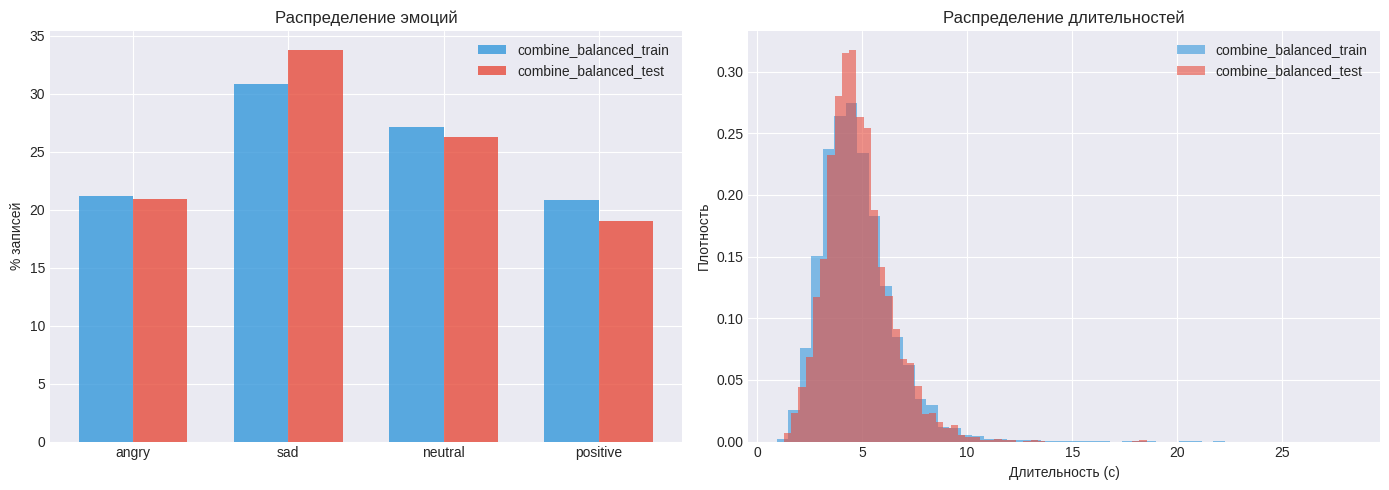

In [9]:
def compare_splits(train_records: list[dict], test_records: list[dict],
                   train_name: str = "train", test_name: str = "test"):
    """Сравнивает train/test: chi2 для эмоций, KS для длительностей."""
    # chi2 test
    train_counts = Counter(r["emotion"] for r in train_records)
    test_counts = Counter(r["emotion"] for r in test_records)
    train_obs = np.array([train_counts.get(e, 0) for e in TARGET_NAMES], dtype=float)
    test_obs = np.array([test_counts.get(e, 0) for e in TARGET_NAMES], dtype=float)

    train_prop = train_obs / train_obs.sum()
    expected = train_prop * test_obs.sum()
    chi2, p_chi2 = stats.chisquare(test_obs, f_exp=expected)

    print("[P] Сравнение train/test:")
    print(f"\n  Эмоции (χ² test):")
    print(f"    χ² = {chi2:.2f}, p = {p_chi2:.4f}", end="")
    print("  [OK] Распределения совпадают"
          if p_chi2 > 0.05 else "  [!]  Распределения отличаются")

    # Tablica proportions
    compare_df = pd.DataFrame({
        "Эмоция": TARGET_NAMES,
        f"{train_name} count": [train_counts.get(e, 0) for e in TARGET_NAMES],
        f"{train_name} %": [round(100 * train_prop[i], 1) for i in range(len(TARGET_NAMES))],
        f"{test_name} count": [test_counts.get(e, 0) for e in TARGET_NAMES],
        f"{test_name} %": [round(100 * test_obs[i] / test_obs.sum(), 1)
                           for i in range(len(TARGET_NAMES))],
        "Δ (%)": [round(100 * (test_obs[i] / test_obs.sum() - train_prop[i]), 1)
                       for i in range(len(TARGET_NAMES))],
    })
    display(compare_df.style.hide(axis="index").format(precision=1))

    # KS test
    train_dur = np.array([r["duration"] for r in train_records if r["duration"] is not None])
    test_dur = np.array([r["duration"] for r in test_records if r["duration"] is not None])
    if len(train_dur) > 0 and len(test_dur) > 0:
        ks_stat, p_ks = stats.ks_2samp(train_dur, test_dur)
        print(f"\n  Длительности (KS test):")
        print(f"    KS = {ks_stat:.4f}, p = {p_ks:.4f}", end="")
        print("  [OK] Распределения совпадают"
              if p_ks > 0.05 else "  [!]  Распределения отличаются")
        print(f"    Train mean={train_dur.mean():.2f}s, "
              f"Test mean={test_dur.mean():.2f}s, "
              f"Δ={test_dur.mean() - train_dur.mean():.2f}s")

    # Проверка на утечку данных (пересечение ID)
    train_ids = set(r["id"] for r in train_records if r["id"])
    test_ids = set(r["id"] for r in test_records if r["id"])
    overlap_ids = train_ids & test_ids
    print(f"\n  Проверка на утечку данных:")
    print(f"    Train IDs ∩ Test IDs = {len(overlap_ids)} "
          f"({100 * len(overlap_ids) / len(train_ids):.1f}% overlap)" if train_ids
          else f"    Train IDs ∩ Test IDs = {len(overlap_ids)}")
    if len(overlap_ids) == 0:
        print("    [OK] Между train и test нет общих записей")
    else:
        print(f"    [!]  Обнаружено {len(overlap_ids)} общих записей!")

    # Визуализация

    # Проверка на утечку по нормализованному тексту
    def _norm(t: str) -> str:
        import re
        return re.sub(r"\s+", " ", t.lower().strip())

    train_texts_norm = set(
        _norm(r["text"]) for r in train_records
        if r.get("text") and r["text"] != "nan"
    )
    test_texts_norm = set(
        _norm(r["text"]) for r in test_records
        if r.get("text") and r["text"] != "nan"
    )
    overlap_texts = train_texts_norm & test_texts_norm
    total_train_texts = len(train_texts_norm)
    total_test_texts = len(test_texts_norm)

    print(f"\n  Проверка по нормализованному тексту (lower+strip):")
    print(f"    Уникальных train-текстов: {total_train_texts}")
    print(f"    Уникальных test-текстов:  {total_test_texts}")
    print(f"    Совпадений:               {len(overlap_texts)} "
              f"({100 * len(overlap_texts) / total_train_texts:.1f}% от train)"
              if total_train_texts
              else f"    Совпадений:               {len(overlap_texts)}")
    if len(overlap_texts) == 0:
        print("    [OK] Совпадений по нормализованному тексту нет")
    else:
        print(f"    [!]  Обнаружено {len(overlap_texts)} общих текстов!")
        sample = sorted(overlap_texts)[:5]
        for s in sample:
            print(f"      • {s[:80]}")
        if len(overlap_texts) > 5:
            print(f"      ... и ещё {len(overlap_texts) - 5}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x = np.arange(len(TARGET_NAMES))
    width = 0.35
    axes[0].bar(x - width / 2,
                [train_prop[i] * 100 for i in range(len(TARGET_NAMES))],
                width, label=train_name, color="#3498db", alpha=0.8)
    axes[0].bar(x + width / 2,
                [test_obs[i] / test_obs.sum() * 100 for i in range(len(TARGET_NAMES))],
                width, label=test_name, color="#e74c3c", alpha=0.8)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(TARGET_NAMES)
    axes[0].set_ylabel("% записей")
    axes[0].set_title("Распределение эмоций")
    axes[0].legend()

    if len(train_dur) > 0 and len(test_dur) > 0:
        axes[1].hist(train_dur, bins=50, alpha=0.6, label=train_name,
                     density=True, color="#3498db")
        axes[1].hist(test_dur, bins=50, alpha=0.6, label=test_name,
                     density=True, color="#e74c3c")
    axes[1].set_xlabel("Длительность (с)")
    axes[1].set_ylabel("Плотность")
    axes[1].set_title("Распределение длительностей")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# Сравниваем combine_balanced train/test
if "combine_balanced_train" in train_data:
    test_cb_path = AGG / "combine_balanced_test.lmdb"
    if test_cb_path.exists():
        print("[...] Загрузка combine_balanced_test dlya sravneniya...")
        test_cb = load_lmdb_metadata(test_cb_path)
        compare_splits(train_data["combine_balanced_train"], test_cb,
                       "combine_balanced_train", "combine_balanced_test")
    else:
        print(f"[MISSING] combine_balanced_test.lmdb ne nayden: {test_cb_path}")

---
## Блок 2 — Test-корпуса

In [10]:
TEST_CORPORA = {
    "combine_balanced_test": AGG / "combine_balanced_test.lmdb",
    "dusha_resd_test": AGG / "dusha_resd_test.lmdb",
}

test_data = {}
for name, path in TEST_CORPORA.items():
    if path.exists():
        print(f"[...] Загрузка {name}...")
        test_data[name] = load_lmdb_metadata(path)
        print(f"  [OK] {name}: {len(test_data[name]):,} записей")
    else:
        print(f"  [MISSING] {name} ОТСУТСТВУЕТ: {path}")

[...] Загрузка combine_balanced_test...


  [OK] combine_balanced_test: 6,392 записей
[...] Загрузка dusha_resd_test...


  [OK] dusha_resd_test: 6,616 записей


### 2.1 Сводная таблица

In [11]:
test_summary = build_summary(test_data)
display(test_summary.style.hide(axis="index").format(
    precision=2,
    subset=["Часов", "Средняя длительность (с)", "Медиана длительность (с)", "% с текстом"]
).format("{:}", subset=["Записей", "angry", "sad", "neutral", "positive"]))

Корпус,Записей,Часов,Средняя длительность (с),Медиана длительность (с),% с текстом,angry,sad,neutral,positive
combine_balanced_test,6392,8.55,4.82,4.60,100.00,1338,2157,1681,1216
dusha_resd_test,6616,8.93,4.86,4.60,100.00,1378,2213,1730,1295


### 2.2 Распределение эмоций

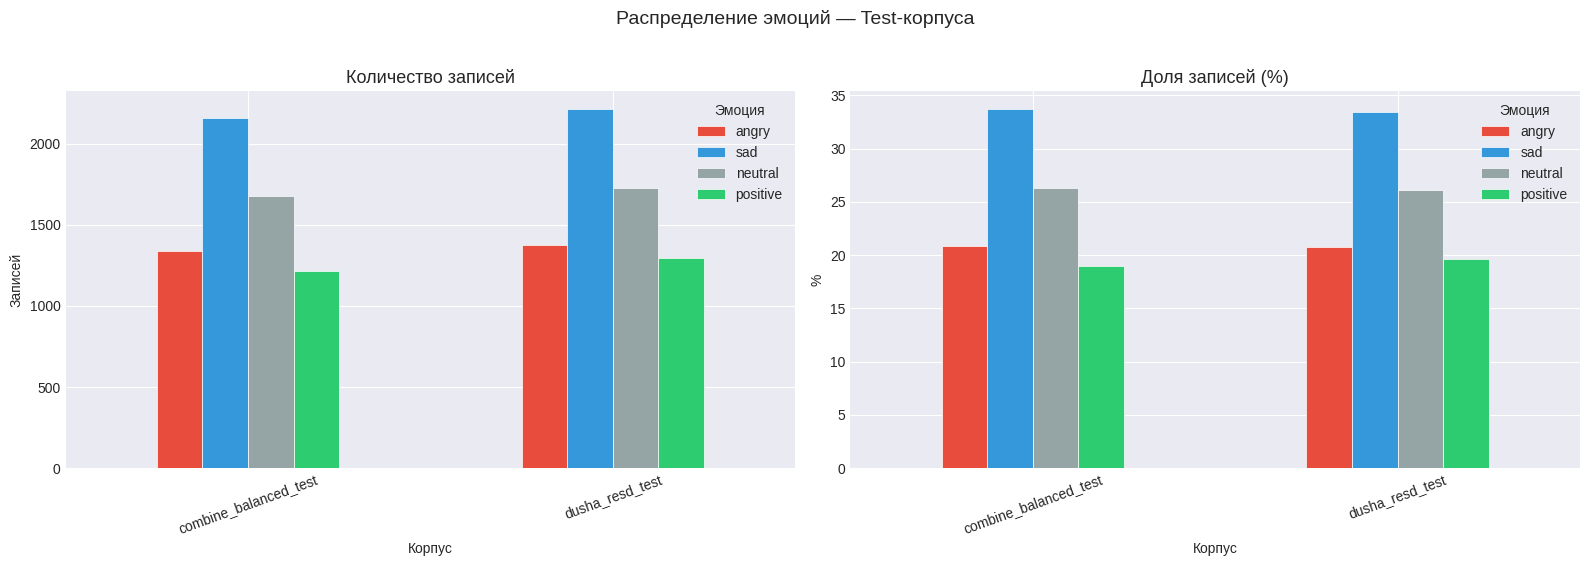


[P] Imbalance ratio (max/min po klassam):
                combine_balanced_test: 1.77x  (min=1,216, max=2,157)
                      dusha_resd_test: 1.71x  (min=1,295, max=2,213)


In [12]:
test_emo_df = plot_emotion_distribution(test_data, "Распределение эмоций — Test-корпуса")

### 2.3 Качество данных

In [13]:
test_quality = check_quality(test_data)

Корпус,Всего,Пустой id,Некорректный y,Пустой text,Waveform = 0,Нет длительности
combine_balanced_test,6392,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
dusha_resd_test,6616,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)


  [OK] combine_balanced_test: все записи валидны
  [OK] dusha_resd_test: все записи валидны


### 2.4 Анализ длительностей

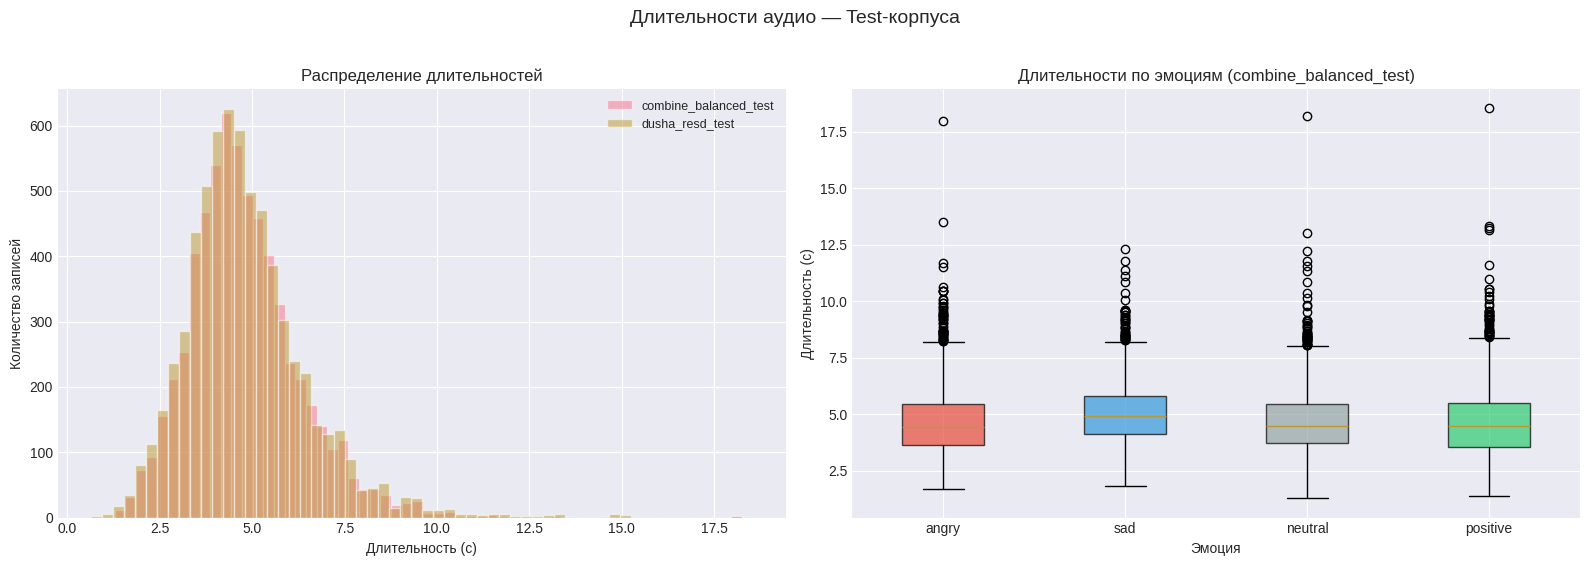

Корпус,N,Mean,Median,Std,Min,P90,P95,Max
combine_balanced_test,6392,4.82,4.60,1.54,1.28,6.78,7.54,18.54
dusha_resd_test,6616,4.86,4.60,1.69,0.64,6.91,7.71,18.54


In [14]:
plot_durations(test_data, "Длительности аудио — Test-корпуса")

### 2.5 Анализ текстов

Корпус,% с текстом
combine_balanced_test,100.0
dusha_resd_test,100.0


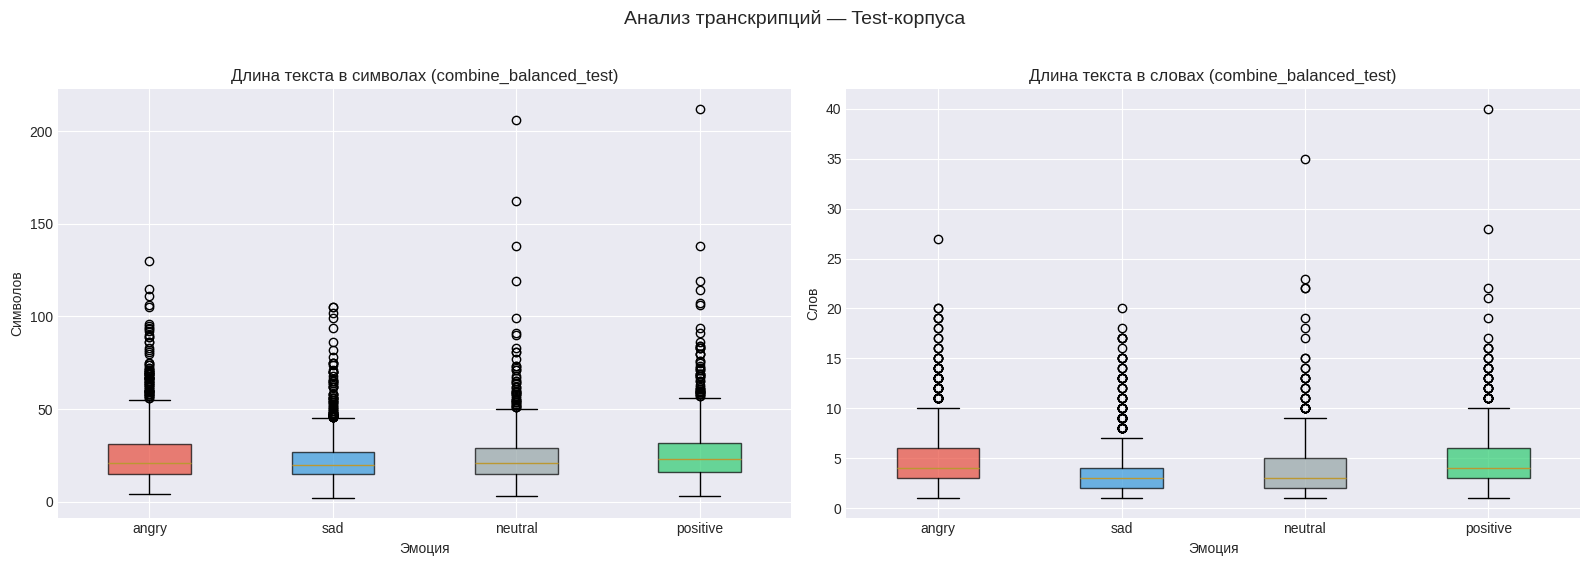

In [15]:
plot_texts(test_data, "Анализ транскрипций — Test-корпуса")

### 2.6 Сравнение train vs test (dusha_resd)

[P] Сравнение train/test:

  Эмоции (χ² test):
    χ² = 24.15, p = 0.0000  [!]  Распределения отличаются


Эмоция,dusha_resd_train count,dusha_resd_train %,dusha_resd_test count,dusha_resd_test %,Δ (%)
angry,14639,21.2,1378,20.8,-0.4
sad,21269,30.8,2213,33.4,2.7
neutral,18703,27.1,1730,26.1,-0.9
positive,14508,21.0,1295,19.6,-1.4



  Длительности (KS test):
    KS = 0.0488, p = 0.0000  [!]  Распределения отличаются
    Train mean=4.78s, Test mean=4.86s, Δ=0.07s

  Проверка на утечку данных:
    Train IDs ∩ Test IDs = 0 (0.0% overlap)
    [OK] Между train и test нет общих записей



  Проверка по нормализованному тексту (lower+strip):
    Уникальных train-текстов: 57928
    Уникальных test-текстов:  6504
    Совпадений:               1842 (3.2% от train)
    [!]  Обнаружено 1842 общих текстов!
      • bullet for my valentine
      • dj играет на фоне достопримечательности
      • downwell блядь включена
      • ego какая глупая
      • glass люблю сюрпризы
      ... и ещё 1837


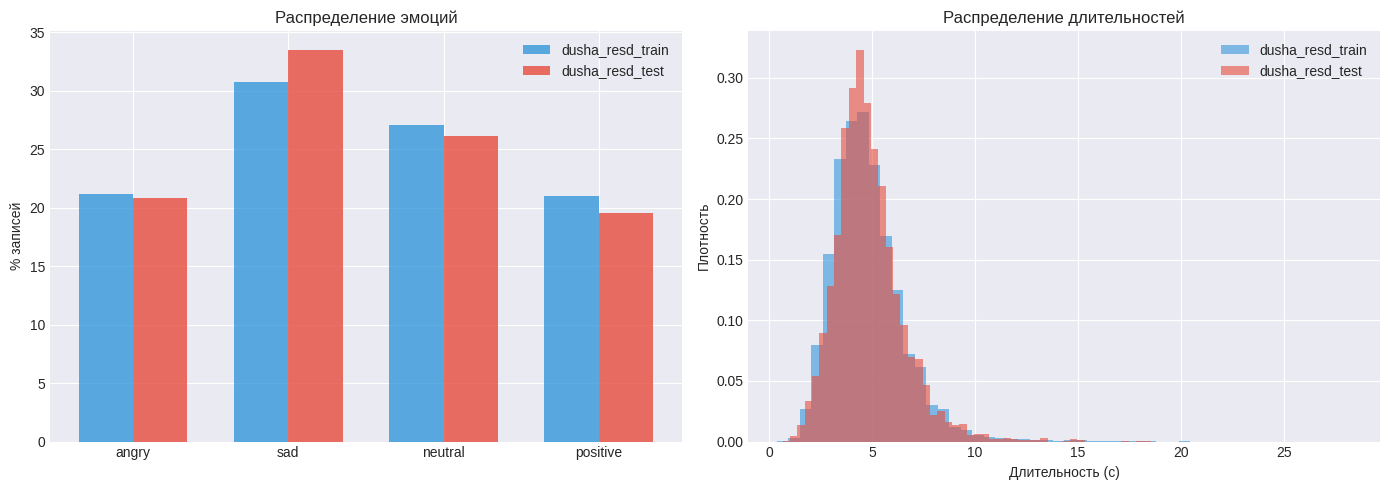

In [16]:
if "dusha_resd_train" in train_data and "dusha_resd_test" in test_data:
    compare_splits(train_data["dusha_resd_train"], test_data["dusha_resd_test"],
                   "dusha_resd_train", "dusha_resd_test")

### 2.7 Пересечение train/test по нормализованному тексту

Проверка на утечку данных по нормализованному тексту (lower + strip).
Количество совпадений показано **от тестового корпуса** — и по уникальным текстам,
и с учётом повторяющихся записей в test.

In [17]:
import re

def _norm(t: str) -> str:
    return re.sub(r"\s+", " ", t.lower().strip())

pairs = [
    ("combine_balanced_train", "combine_balanced_test"),
    ("dusha_resd_train", "dusha_resd_test"),
]

rows = []
for tr, te in pairs:
    if tr not in train_data or te not in test_data:
        continue
    tr_recs = train_data[tr]
    te_recs = test_data[te]

    tr_norm = {_norm(r.get("text")) for r in tr_recs
               if r.get("text") and r.get("text") != "nan"}
    te_norm = {_norm(r.get("text")) for r in te_recs
               if r.get("text") and r.get("text") != "nan"}
    te_texts_list = [_norm(r.get("text")) for r in te_recs
                     if r.get("text") and r.get("text") != "nan"]

    overlap_unique = tr_norm & te_norm
    n_test_unique = len(te_norm)
    n_test_total = len(te_texts_list)
    n_test_with_dup = sum(1 for t in te_texts_list if t in tr_norm)

    rows.append({
        "Пара": f"{tr} → {te}",
        "Test записей с текстом": n_test_total,
        "Test уникальных текстов": n_test_unique,
        "Совпало (уник.)": len(overlap_unique),
        "% от test (уник.)": round(100 * len(overlap_unique) / n_test_unique, 1)
                             if n_test_unique else 0,
        "Совпало (с повт.)": n_test_with_dup,
        "% от test (с повт.)": round(100 * n_test_with_dup / n_test_total, 1)
                               if n_test_total else 0,
        "Train уникальных": len(tr_norm),
    })

overlap_norm_df = pd.DataFrame(rows)
display(overlap_norm_df.style.hide(axis="index").format(
    precision=1,
    subset=["% от test (уник.)", "% от test (с повт.)"]
))


Пара,Test записей с текстом,Test уникальных текстов,Совпало (уник.),% от test (уник.),Совпало (с повт.),% от test (с повт.),Train уникальных
combine_balanced_train → combine_balanced_test,6392,6280,1840,29.3,1845,28.9,57015
dusha_resd_train → dusha_resd_test,6616,6504,1842,28.3,1847,27.9,57928


---
## 📋 Итоговая сводка: train vs test

Корпус,Split,Записей,Часов,Средняя длит. (с),% с текстом,angry,sad,neutral,positive
combine_balanced_train,train,68203,90.31,4.77,98.20,14435,21049,18520,14199
combine_balanced_train_small,train,20474,27.05,4.76,98.20,4344,6337,5564,4229
dusha_resd_train,train,69119,91.84,4.78,98.20,14639,21269,18703,14508
combine_balanced_test,test,6392,8.55,4.82,100.00,1338,2157,1681,1216
dusha_resd_test,test,6616,8.93,4.86,100.00,1378,2213,1730,1295


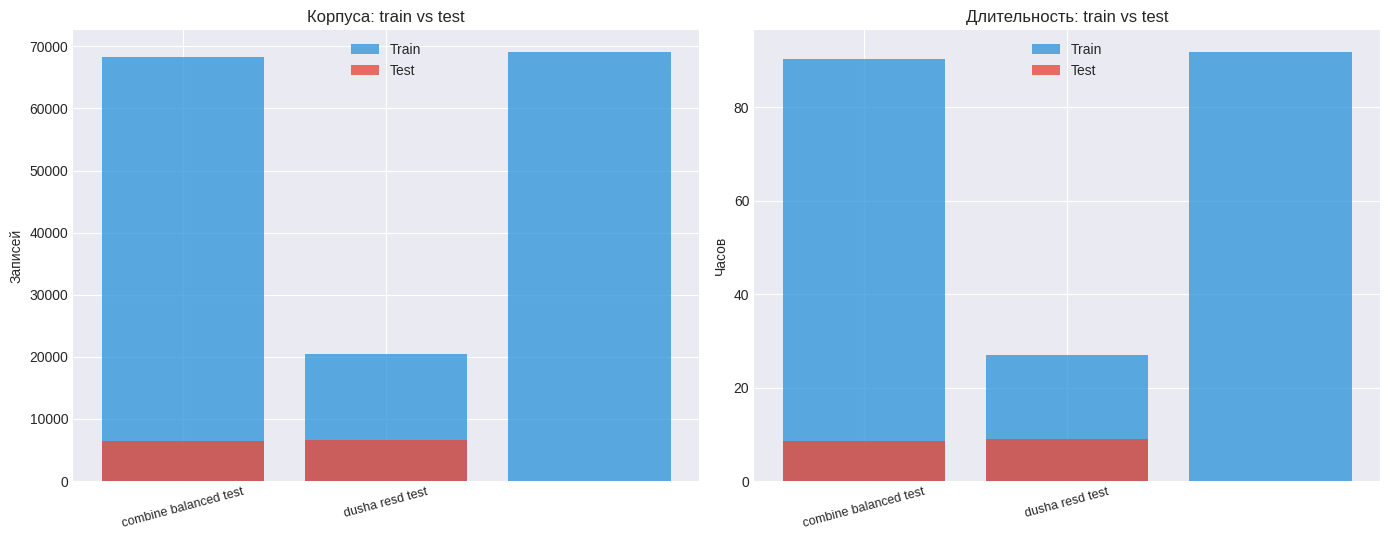

In [18]:
all_summary = []
for name, records in {**train_data, **test_data}.items():
    durations = [r["duration"] for r in records if r["duration"] is not None]
    texts = [r["text"] for r in records if r["text"] and r["text"] != "nan"]
    emo_counts = Counter(r["emotion"] for r in records)
    total_hours = sum(durations) / 3600 if durations else 0
    all_summary.append({
        "Корпус": name,
        "Split": "train" if "train" in name else "test",
        "Записей": len(records),
        "Часов": round(total_hours, 2),
        "Средняя длит. (с)": round(np.mean(durations), 2) if durations else 0,
        "% с текстом": round(100 * len(texts) / len(records), 1) if records else 0,
        "angry": emo_counts.get("angry", 0),
        "sad": emo_counts.get("sad", 0),
        "neutral": emo_counts.get("neutral", 0),
        "positive": emo_counts.get("positive", 0),
    })

final_df = pd.DataFrame(all_summary)
display(final_df.style.hide(axis="index").format(
    precision=2,
    subset=["Часов", "Средняя длит. (с)", "% с текстом"]
).format("{:}", subset=["Записей", "angry", "sad", "neutral", "positive"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for split_name, split_label, color in [("train", "Train", "#3498db"), ("test", "Test", "#e74c3c")]:
    split_rows = [r for r in all_summary if r["Split"] == split_name]
    if split_rows:
        labels = [r["Корпус"].replace("_", " ") for r in split_rows]
        values = [r["Записей"] for r in split_rows]
        x = np.arange(len(labels))
        axes[0].bar(x, values, label=split_label, color=color, alpha=0.8)
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(labels, rotation=15, fontsize=9)

axes[0].set_ylabel("Записей")
axes[0].set_title("Корпуса: train vs test")
axes[0].legend()

for split_name, split_label, color in [("train", "Train", "#3498db"), ("test", "Test", "#e74c3c")]:
    split_rows = [r for r in all_summary if r["Split"] == split_name]
    if split_rows:
        labels = [r["Корпус"].replace("_", " ") for r in split_rows]
        values = [r["Часов"] for r in split_rows]
        x = np.arange(len(labels))
        axes[1].bar(x, values, label=split_label, color=color, alpha=0.8)
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(labels, rotation=15, fontsize=9)

axes[1].set_ylabel("Часов")
axes[1].set_title("Длительность: train vs test")
axes[1].legend()

plt.tight_layout()
plt.show()